# Spotify Playlist Explorer

Phase 1 demo (Sprint C, final): authenticate, pick a playlist (or your
Liked Songs), run six analyzers (genres, release year, top artists,
popularity, duration, timeline) with coordinated colorblind palette and
inline coverage annotations, render plots, and optionally export to parquet.

Setup: load credentials from `.env`, set the seaborn theme, and build a
cached `SpotifyClient`. The cache lives at the repo's `.cache/api/` folder
regardless of where the notebook is launched from (7-day TTL), so repeated
notebook runs don't re-hit the API.

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from spotify_project.analyzer import (
    Analyzer,
    ArtistAnalyzer,
    DurationAnalyzer,
    GenreAnalyzer,
    PlaylistAnalyzer,
    PopularityAnalyzer,
    TimelineAnalyzer,
    YearAnalyzer,
)
from spotify_project.cache import FileCache
from spotify_project.client import SpotifyClient
from spotify_project.logging_setup import configure_logging

load_dotenv()

# Two log levels: APP for our own code (spotify_project.*), THIRD_PARTY for spotipy / urllib3.
# THIRD_PARTY default is WARNING because spotipy DEBUG dumps Authorization headers and API
# responses into stderr. configure_logging also installs a redaction filter (defense-in-depth).
APP_LOG_LEVEL = os.getenv("APP_LOG_LEVEL", "INFO")
THIRD_PARTY_LOG_LEVEL = os.getenv("THIRD_PARTY_LOG_LEVEL", "WARNING")
configure_logging(APP_LOG_LEVEL, THIRD_PARTY_LOG_LEVEL)

sns.set_theme(style="whitegrid")
cache = FileCache()
client = SpotifyClient.from_env(cache=cache)

## 1. Confirm authentication

In [16]:
user = client.fetch_current_user()
truncated_name = user.display_name[0] + "***" if user.display_name else "Unknown"
user_id_present = "YES" if user.id else "NO"
print(f"Hello, {truncated_name} (UserID present: {user_id_present})")

Hello, B*** (UserID present: YES)


## 2. List your playlists

Spotify renamed `tracks` → `items` in their Feb 2026 migration. The `items` field is only present on playlists you own or collaborate on; for followed playlists, `tracks` reads as 0.

In [17]:
import pandas as pd

playlists = client.fetch_user_playlists()
summary = pd.DataFrame(
    [
        {
            "id": p.id,
            "name": p.name,
            "tracks": p.track_count,
            "owner": p.owner_name,
        }
        for p in playlists
    ]
)
summary.head(20)

,id,name,tracks,owner
0,7CmreRETnY6t2MdHrIiaIA,Top 100 Doo Wop Hits 1953-1964,99,Hunter Pratt
1,36qmhWCGOAJt6pRScmHcyb,GTA 6 Soundtrack | 2026 GTA VI 🔥🎮,70,Magenta
2,3ebHKSjHujS4Tyt2KKP97R,Retrowave Synthwave,75,Cheerzo
3,0O3NMz7IEQJCLtO6tXLaq1,Surf Rock Classics,96,awaterslideaway
4,2ZHmECo8IsjfyWDKo0XwfC,Special Groove,37,Timothy Hale
5,5sDWiz1XZevt4T2qOOir50,Liens hochzeit,4,Bretos
6,3v8PWRLiPHGPY0oHgkoZvV,Ben Böhmer [Not Live],20,Bretos
7,5HMBUSi7dMH6N4l0ME6rzE,Chris Tmas,13,Bretos
8,1oMfydMymnL1wQBxiZStDj,Loopthat,1,Bretos
9,0x3U0VtCmPBEImdkpk177b,Rave In Your Grave,142,Timothy Hale


## 3. Pick a playlist and fetch it

Replace `PLAYLIST_ID` below with one of the IDs from the table above.

In [18]:
PLAYLIST_ID = "3v8PWRLiPHGPY0oHgkoZvV"  # or "__liked__" for your saved tracks # 3v8PWRLiPHGPY0oHgkoZvV
playlist = client.fetch_liked_songs() if PLAYLIST_ID == "__liked__" else client.fetch_playlist(PLAYLIST_ID)  # pyright: ignore[reportUnnecessaryComparison]
print(f"{playlist.name}: {len(playlist.tracks)} tracks")

spotify_project.client - INFO - Enriching 20 tracks with artist data
spotify_project.client - INFO - Fetching 14 unique artists (~4 s estimate)


Ben Böhmer [Not Live]: 20 tracks


## 4. Build the PlaylistAnalyzer with all six analyzers

Tweak knobs here:
- `YearAnalyzer(bucket_size=10)` for decade buckets — set to `1` for per-year bars.
- `ArtistAnalyzer(primary_only=True)` to ignore collaborators.
- `TimelineAnalyzer(freq='Y')` for yearly buckets instead of monthly.

Each analyzer reports a small summary DataFrame. Numbers come from the
flattened track DataFrame produced by `PlaylistAnalyzer.from_playlist`.
Coverage attached to each summary surfaces in the chart titles below.

In [19]:
analyzers: list[Analyzer] = [
    GenreAnalyzer(top_n=15),
    YearAnalyzer(bucket_size=10),
    ArtistAnalyzer(top_n=15, primary_only=False),
    PopularityAnalyzer(bins=10),
    DurationAnalyzer(bins=20),
    TimelineAnalyzer(freq="M"),
]
analyzer = PlaylistAnalyzer.from_playlist(playlist, analyzers=analyzers)
results = analyzer.run_all()
for title, df in results.items():
    print(title)
    print(df.head(), end="\n\n")

spotify_project.analyzer - WARNING - Top Genres: low coverage 0/20 (0%)


Top Genres
Empty DataFrame
Columns: [genre, count]
Index: []

Release Year Distribution
   year  count
0  2010      7
1  2020     13

Top Artists
                artist_id     artist_name  track_count  total_minutes
0  5tDjiBYUsTqzd0RkTZxK7u      Ben Böhmer           20      96.230700
1  3Rmw0IldYoch0L6XmTjQO4           JONAH            2       7.477450
2  2nq2BeSbzExGAv3Y4HgUf7  Stephan Bodzin            2      13.813383
3  2I4hRNCYkPKJQlkoEZKjYx        Monolink            1       5.311233
4  3W9UldYu0xJcaOAw2SUTDI          Panama            1       4.391333

Popularity Distribution
   bin_low  bin_high  count
0      0.0      10.0     20
1     10.0      20.0      0
2     20.0      30.0      0
3     30.0      40.0      0
4     40.0      50.0      0

Track Duration Distribution
    bin_low  bin_high  count  minutes_in_bin
0  2.696000  2.961451      1        2.696000
1  2.961451  3.226902      0        0.000000
2  3.226902  3.492352      0        0.000000
3  3.492352  3.757803      2    

## 5. Render plots

All six panels stack vertically, each in a distinct colorblind-safe color.
`GenreAnalyzer` shows a small grey band at the bottom whenever some
tracks have no genre data — a common case for editorial playlists.

spotify_project.analyzer - WARNING - Top Genres: low coverage 0/20 (0%)


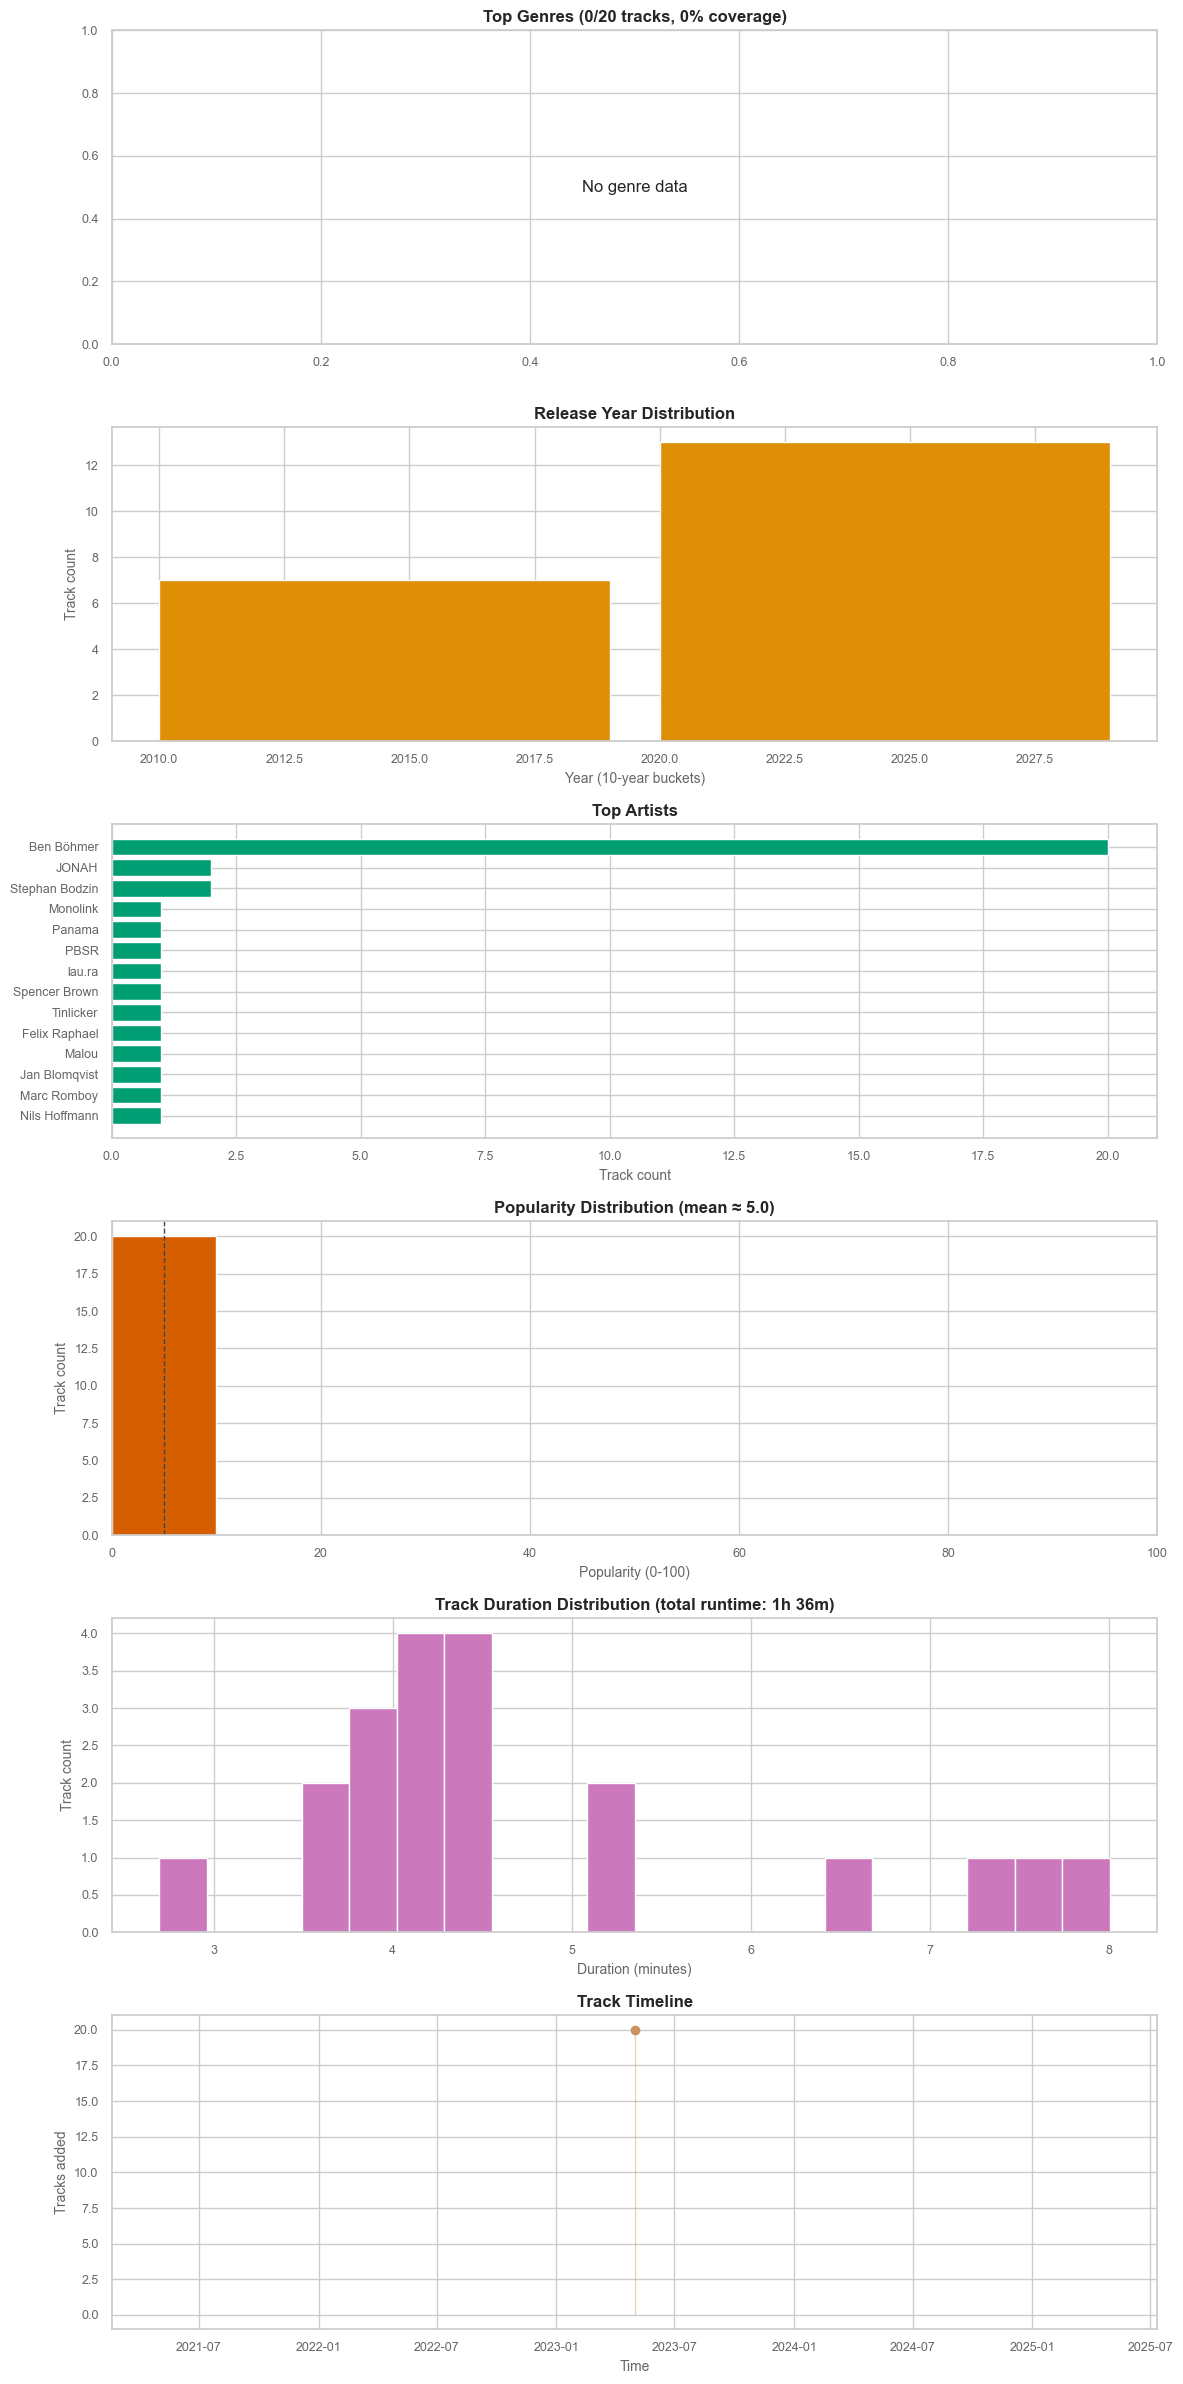

In [20]:
fig = plt.figure(figsize=(12, 24))  # pyright: ignore[reportUnknownMemberType]
analyzer.plot_all(fig)
plt.show()  # pyright: ignore[reportUnknownMemberType]

## 6. (Optional) Export the flattened track DataFrame to parquet

Useful for offline analysis in another tool, or for archiving the snapshot
you analyzed today.

The exported parquet preserves the full flattened track DataFrame (track
id/name, primary artist, all artists, album, release date, duration in
minutes, popularity, added_at, genres). Useful for archiving the
snapshot you analyzed today.

In [21]:
EXPORT = False  # set True to write the file
if EXPORT:
    out = Path("exports") / f"{playlist.id}.parquet"
    out.parent.mkdir(parents=True, exist_ok=True)
    analyzer.to_parquet(out)
    print(f"wrote {out}")